# STEP 1: IMPORT NECESSARY LIBRARIES

In [111]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import re
import numpy as np

# Step 2: EXTRACT DATA FROM LOCAL FILE

In [ ]:
data=pd.read_excel(r"C:\TSA_PROJECT\commute_mode.xlsx")
data

,Transportation Method,Workers 16 years and over,16 to 19 years,20 to 24 years,25 to 44 years,45 to 54 years,55 to 59 years,60 years and over,Median age (years),Male,...,Commute Time 35 to 44 minutes,Commute Time 45 to 59 minutes,Commute Time 60 or more minutes,Commute Time Mean travel time to work (minutes),Owner-occupied housing units,Renter-occupied housing units,No vehicle available,1 vehicle available,2 vehicles available,3 or more vehicles available
0,Total Estimate,162434675,0.037,0.092,0.442,0.197,0.089,0.143,41.7,0.528,...,0.073,0.081,0.089,26.8,0.675,0.325,0.046,0.214,0.397,0.342
1,"Car, truck, or van -- drove alone Estimate",112376082,0.035,0.092,0.434,0.199,0.093,0.148,42.2,0.541,...,0.074,0.079,0.077,26.1,0.699,0.301,0.017,0.199,0.412,0.372
2,"Car, truck, or van -- carpooled Estimate",14609627,0.072,0.122,0.454,0.187,0.069,0.097,38.4,0.504,...,0.07,0.08,0.095,27.2,0.620,0.380,0.050,0.213,0.364,0.373
3,Public transportation (excluding taxicab) Esti...,5735258,0.029,0.111,0.494,0.171,0.075,0.120,38.5,0.500,...,0.112,0.173,0.361,48.9,0.385,0.615,0.394,0.311,0.189,0.105
4,Worked from home Estimate,22486510,0.013,0.048,0.475,0.212,0.092,0.160,43.5,0.477,...,(X),(X),(X),(X),0.729,0.271,0.045,0.244,0.436,0.274


In [115]:
df = data.iloc[1:]  # keeps all rows except the first
df

,Transportation Method,Workers 16 years and over,16 to 19 years,20 to 24 years,25 to 44 years,45 to 54 years,55 to 59 years,60 years and over,Median age (years),Male,...,Commute Time 35 to 44 minutes,Commute Time 45 to 59 minutes,Commute Time 60 or more minutes,Commute Time Mean travel time to work (minutes),Owner-occupied housing units,Renter-occupied housing units,No vehicle available,1 vehicle available,2 vehicles available,3 or more vehicles available
1,"Car, truck, or van -- drove alone Estimate",112376082,0.035,0.092,0.434,0.199,0.093,0.148,42.2,0.541,...,0.074,0.079,0.077,26.1,0.699,0.301,0.017,0.199,0.412,0.372
2,"Car, truck, or van -- carpooled Estimate",14609627,0.072,0.122,0.454,0.187,0.069,0.097,38.4,0.504,...,0.07,0.08,0.095,27.2,0.620,0.380,0.050,0.213,0.364,0.373
3,Public transportation (excluding taxicab) Esti...,5735258,0.029,0.111,0.494,0.171,0.075,0.120,38.5,0.500,...,0.112,0.173,0.361,48.9,0.385,0.615,0.394,0.311,0.189,0.105
4,Worked from home Estimate,22486510,0.013,0.048,0.475,0.212,0.092,0.160,43.5,0.477,...,(X),(X),(X),(X),0.729,0.271,0.045,0.244,0.436,0.274


# Step 3: DATA CLEANING

In [110]:
#Step 3: Data Cleaning
# Sample data--After remove strings and first row of data
df = pd.DataFrame({
   "Transportation Method":["1","2","3","4"],
   "Workers 16 years and over":["112,376,082","14,609,627","5,735,258","22,486,510"],
    "16 to 19 years":["3.50%","7.20%","2.90%","1.30%"],
    "20 to 24 years":["9.20%","12.20%","11.10%","4.80%"],
    "25 t0 45 years":["43.40%","45.40%","49.40%","47.50%"],
    "45 to 54 years":["19.90%","18.70%","17.10%","21.20%"],
    "55 to 59 years":["9.30%","6.90%","7.50%","9.20%"],
    "60 years and over":["14.80%","9.70%","12.00%","16.00%"],
    "Male":["54.10%","50.40%","50.00%","47.70%"],
    "Female":["45.90%","49.60%","50.00%","52.30%"],
    "Native":["84.20%","73.60%","64.90%","84.30%"],
    "Foreign born":["15.80%","26.40%","35.10%","15.70%"],
    "Naturalized U.S. citizen":["8.80%","10.80%","16.30%","9.40%"],
    "Not a U.S. citizen":["7.10%","15.60%","18.80%","6.20%"],
    "Speak language other than English":["21.80%","36.10%","40.20%","19.40%"],
    "$1 to $9,999 or loss EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["8.30%","13.50%","10.30%","6.70%"],
    "$10,000 to $14,999 EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["4.60%","6.30%","5.50%","3.60%"],
    "$15,000 to $24,999 EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["9.60%","13.10%","11.00%","6.30%"],
    "$25,000 to $34,999 EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["11.50%","14.60%","11.50%","6.80%"],
    "$35,000 to $49,999 EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["17.20%","17.80%","13.60%","11.50%"],
    "$50,000 to $64,999 EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["14.60%","12.30%","10.40%","11.80%"],
    "$65,000 to $74,999 EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["6.80%","5.00%","5.10%","6.50%"],
    "$75,000 or more EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["27.40%","17.50%","32.60%","46.70%"],
    "Median earnings (dollars) EARNINGS IN THE PAST 12 MONTHS (IN 2023 INFLATION-ADJUSTED DOLLARS) FOR WORKERS":["48,372","36,479","46,903","70,280"],
    "Below 100 percent of the poverty level":["5.10%","7.70%","9.30%","3.60%"],
    "100 to 149 percent of the poverty level":["4.90%","7.40%","6.40%","2.90%"],
    "At or above 150 percent of the poverty level":["90.00%","84.90%","84.20%","93.50%"],
    "Management, business, science, and arts occupations":["40.60%","32.50%","45.00%","63.90%"],
    "Service occupations":["16.50%","21.00%","23.10%","7.70%"],
    "Sales and office occupations":["18.90%","17.80%","17.60%","21.20%"],
    "Natural resources, construction, and maintenance occupations":["9.30%","12.20%","4.80%","3.00%"],
    "Production, transportation, and material moving occupations":["14.30%","16.10%","9.40%","4.00%"],
    "Military specific occupations":["0.40%","0.40%","0.20%","0.20%"],
    "Agriculture, forestry, fishing and hunting, and mining":["1.50%","2.00%","0.60%","1.30%"],
    "Construction":["7.40%","9.70%","4.00%","3.70%"],
    "Manufacturing":["10.80%","10.20%","4.50%","7.50%"],
    "Wholesale trade":["2.10%","1.80%","1.30%","2.10%"],
    "Retail trade":["11.20%","11.70%","9.80%","6.40%"],
    "Transportation and warehousing, and utilities":["6.60%","5.40%","4.80%","3.50%"],
    "Information and finance and insurance, and real estate and rental and leasing":["6.80%","5.10%","12.50%","18.20%"],
    "Professional, scientific, management, and administrative and waste management services":["10.00%","9.90%","16.90%","27.60%"],
    "Educational services, and health care and social assistance":["24.40%","23.10%","23.40%","16.90%"],
    "Arts, entertainment, and recreation, and accommodation and food services":["8.60%","11.80%","12.60%","4.10%"],
    "Other services (except public administration)":["4.80%","5.00%","4.60%","4.10%"],
    "Public administration":["5.00%","3.40%","4.60%","4.20%"],
    "Armed forces":["0.80%","0.80%","0.30%","0.30%"],
    "Private wage and salary workers":["78.70%","78.50%","82.70%","79.70%"],
    "Government workers":["16.30%","15.20%","13.80%","9.40%"],
    "Self-employed workers in own not incorporated business":["4.90%","6.00%","3.30%","10.70%"],
    "Unpaid family workers":["0.10%","0.30%","0.20%","0.30%"],
    "Worked in state of residence":["96.50%","96.60%","90.00%","100.00%"],
    "TIME OF DEPARTURE TO GO TO WORK 12:00 a.m. to 4:59 a.m.":["5.50%","5.50%","3.80%","0.00"],
    "TIME OF DEPARTURE TO GO TO WORK 5:00 a.m. to 5:29 a.m.":["4.10%","4.50%","3.20%","0.00"],
    "TIME OF DEPARTURE TO GO TO WORK 6:00 a.m. to 6:29 a.m.":["8.70%","8.80%","7.70%","0.0"],
    "TIME OF DEPARTURE TO GO TO WORK 6:30 a.m. to 6:59 a.m.":["9.80%","9.70%","7.00%","0.0"],
    "TIME OF DEPARTURE TO GO TO WORK 7:00 a.m. to 7:29 a.m.":["14.60%","14.80%","14.20%","0.0"],
    "TIME OF DEPARTURE TO GO TO WORK 7:30 a.m. to 7:59 a.m.":["12.40%","10.60%","10.00%","0.0"]
})
# Remove , and % from every column (if it's string type)
df= df.map(lambda x: str(x).replace(",", "").replace("%", ""))
print(df)



  Transportation Method Workers 16 years and over 16 to 19 years  \
0                     1                 112376082           3.50   
1                     2                  14609627           7.20   
2                     3                   5735258           2.90   
3                     4                  22486510           1.30   

  20 to 24 years 25 t0 45 years 45 to 54 years 55 to 59 years  \
0           9.20          43.40          19.90           9.30   
1          12.20          45.40          18.70           6.90   
2          11.10          49.40          17.10           7.50   
3           4.80          47.50          21.20           9.20   

  60 years and over   Male Female  ... Government workers  \
0             14.80  54.10  45.90  ...              16.30   
1              9.70  50.40  49.60  ...              15.20   
2             12.00  50.00  50.00  ...              13.80   
3             16.00  47.70  52.30  ...               9.40   

  Self-employed workers in 

In [97]:
new_df=df
new_df

,Transportation Method,Workers 16 years and over,16 to 19 years,20 to 24 years,25 t0 45 years,45 to 54 years,55 to 59 years,60 years and over,Male,Female,...,Government workers,Self-employed workers in own not incorporated business,Unpaid family workers,Worked in state of residence,TIME OF DEPARTURE TO GO TO WORK 12:00 a.m. to 4:59 a.m.,TIME OF DEPARTURE TO GO TO WORK 5:00 a.m. to 5:29 a.m.,TIME OF DEPARTURE TO GO TO WORK 6:00 a.m. to 6:29 a.m.,TIME OF DEPARTURE TO GO TO WORK 6:30 a.m. to 6:59 a.m.,TIME OF DEPARTURE TO GO TO WORK 7:00 a.m. to 7:29 a.m.,TIME OF DEPARTURE TO GO TO WORK 7:30 a.m. to 7:59 a.m.
0,1,112376082,3.50,9.20,43.40,19.90,9.30,14.80,54.10,45.90,...,16.30,4.90,0.10,96.50,5.50,4.10,8.70,9.80,14.60,12.40
1,2,14609627,7.20,12.20,45.40,18.70,6.90,9.70,50.40,49.60,...,15.20,6.00,0.30,96.60,5.50,4.50,8.80,9.70,14.80,10.60
2,3,5735258,2.90,11.10,49.40,17.10,7.50,12.00,50.00,50.00,...,13.80,3.30,0.20,90.00,3.80,3.20,7.70,7.00,14.20,10.00
3,4,22486510,1.30,4.80,47.50,21.20,9.20,16.00,47.70,52.30,...,9.40,10.70,0.30,100.00,0.00,0.00,0.0,0.0,0.0,0.0


# Step 4: Visualization (Charts and Graphs)

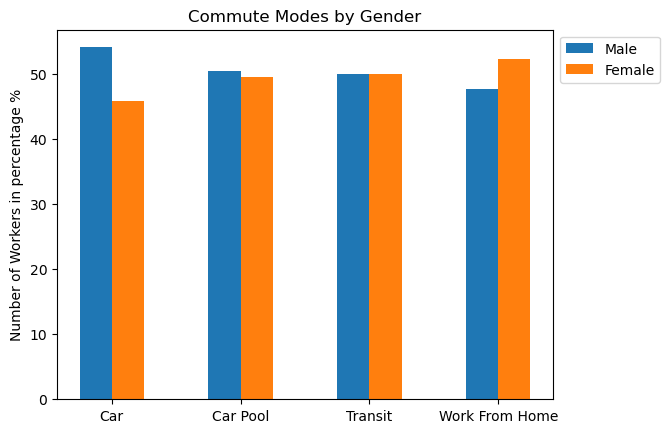

In [7]:
# Graph 1:Commute Modes by Gender
#Categories
trans_modes=["Car","Car Pool","Transit","Work From Home"]
#Values for 2 groups
male=[54.10,50.40,50.00,47.70]
female=[45.90,49.60,50.00,52.30]
#setup bar positions
x=np.arange(len(trans_modes)) #positions for groups
width=0.25

#Plot bars side by side
plt.bar(x-width/2,male,width,label="Male")
plt.bar(x+width/2,female,width,label="Female")
#Formatting
plt.xticks(x,trans_modes)
plt.ylabel("Number of Workers in percentage %")
plt.title("Commute Modes by Gender")
plt.legend(bbox_to_anchor=(1.0,1), loc='upper left')
plt.show()

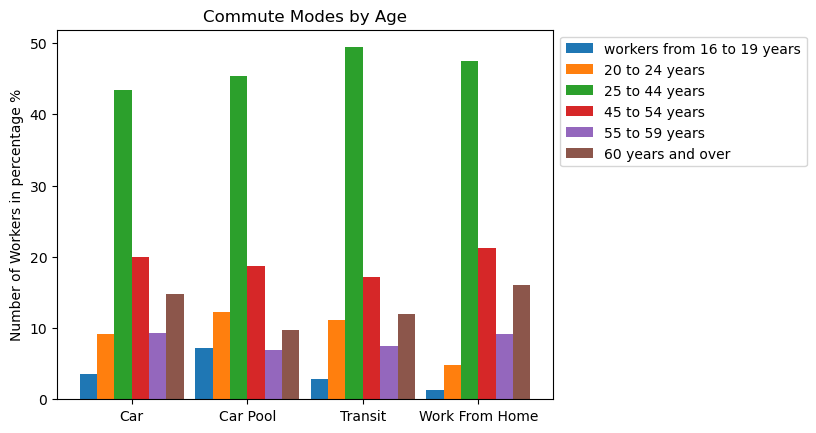

In [112]:
# Graph 2:
trans=["Car","Car Pool","Transit","Work From Home"]
age_16to19years=[3.50,7.20,2.90,1.30]
age_20to24years=[9.20,12.20,11.10,4.80]
age_25to44years=[43.40,45.40,49.40,47.50]
age_45to54years=[19.90,18.70,17.10,21.20]
age_55to59years=[9.30,6.90,7.50,9.20]
age_60yearsandover=[14.80,9.70,12.00,16.00]
#setup bar positions
x=np.arange(len(trans_modes)) #positions for groups
width=0.15

#Plot bars side by side
plt.bar(x-2.5*width,age_16to19years,width,label="workers from 16 to 19 years")
plt.bar(x-1.5*width,age_20to24years,width,label="20 to 24 years")
plt.bar(x-0.5*width,age_25to44years,width,label="25 to 44 years")
plt.bar(x+0.5*width,age_45to54years,width,label="45 to 54 years")
plt.bar(x+1.5*width,age_55to59years,width,label="55 to 59 years")
plt.bar(x+2.5*width,age_60yearsandover,width,label="60 years and over")
#Formatting
plt.xticks(x,trans_modes)
plt.ylabel("Number of Workers in percentage %")
plt.title("Commute Modes by Age")
plt.legend(bbox_to_anchor=(1.0,1), loc='upper left')
plt.show()

#fig=px.pie(data,values=age,names=trans,title='Age wise transportation method')
#fig.update_layout(autosize=False,width=800,height=600,paper_bgcolor="lightyellow")
#fig.show()

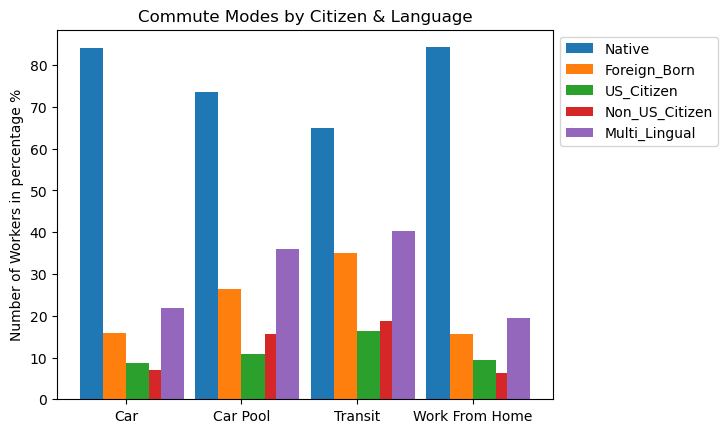

In [11]:
# Graph 3
#Categories
trans_modes=["Car","Car Pool","Transit","Work From Home"]
#Values for 5 groups
Native=[84.20,73.60,64.90,84.30]
Foreign_Born=[15.80,26.40,35.10,15.70]
US_Citizen=[8.80,10.80,16.30,9.40]
Non_US_Citizen=[7.10,15.60,18.80,6.20]
Multi_Lingual=[21.80,36.10,40.20,19.40]
#setup bar positions
x=np.arange(len(trans_modes)) #positions for groups
width=0.2

#Plot bars side by side
plt.bar(x-1.5*width,Native,width,label="Native")
plt.bar(x-0.5*width,Foreign_Born,width,label="Foreign_Born")
plt.bar(x+0.5*width,US_Citizen,width,label="US_Citizen")
plt.bar(x+1.5*width,Non_US_Citizen,width,label="Non_US_Citizen")
plt.bar(x+2.0*width,Multi_Lingual,width,label="Multi_Lingual")
#Formatting
plt.xticks(x,trans_modes)
plt.ylabel("Number of Workers in percentage %")
plt.title("Commute Modes by Citizen & Language")
plt.legend(bbox_to_anchor=(1.0,1), loc='upper left')
plt.show()


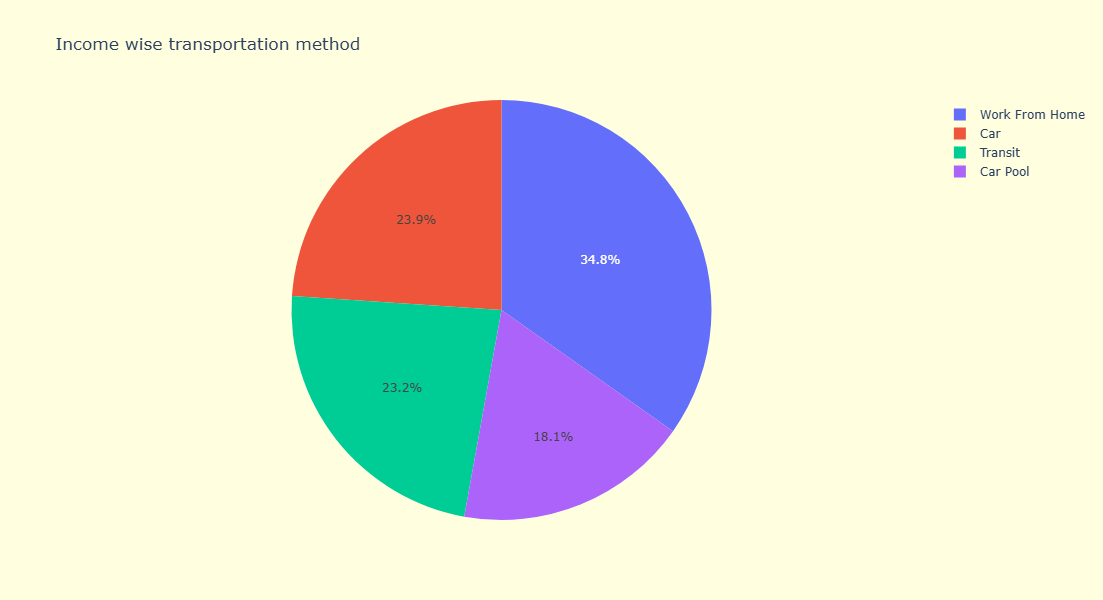

In [13]:
# Graph 4:
#Categories
trans_modes=["Car","Car Pool","Transit","Work From Home"]
#Values for 5 groups
salary=[48372,36479,46903,70280] #Take a median salary for pie chart
fig=px.pie(data,values=salary,names=trans_modes,title='Income wise transportation method')
fig.update_layout(autosize=False,width=800,height=600,paper_bgcolor="lightyellow")
fig.show()

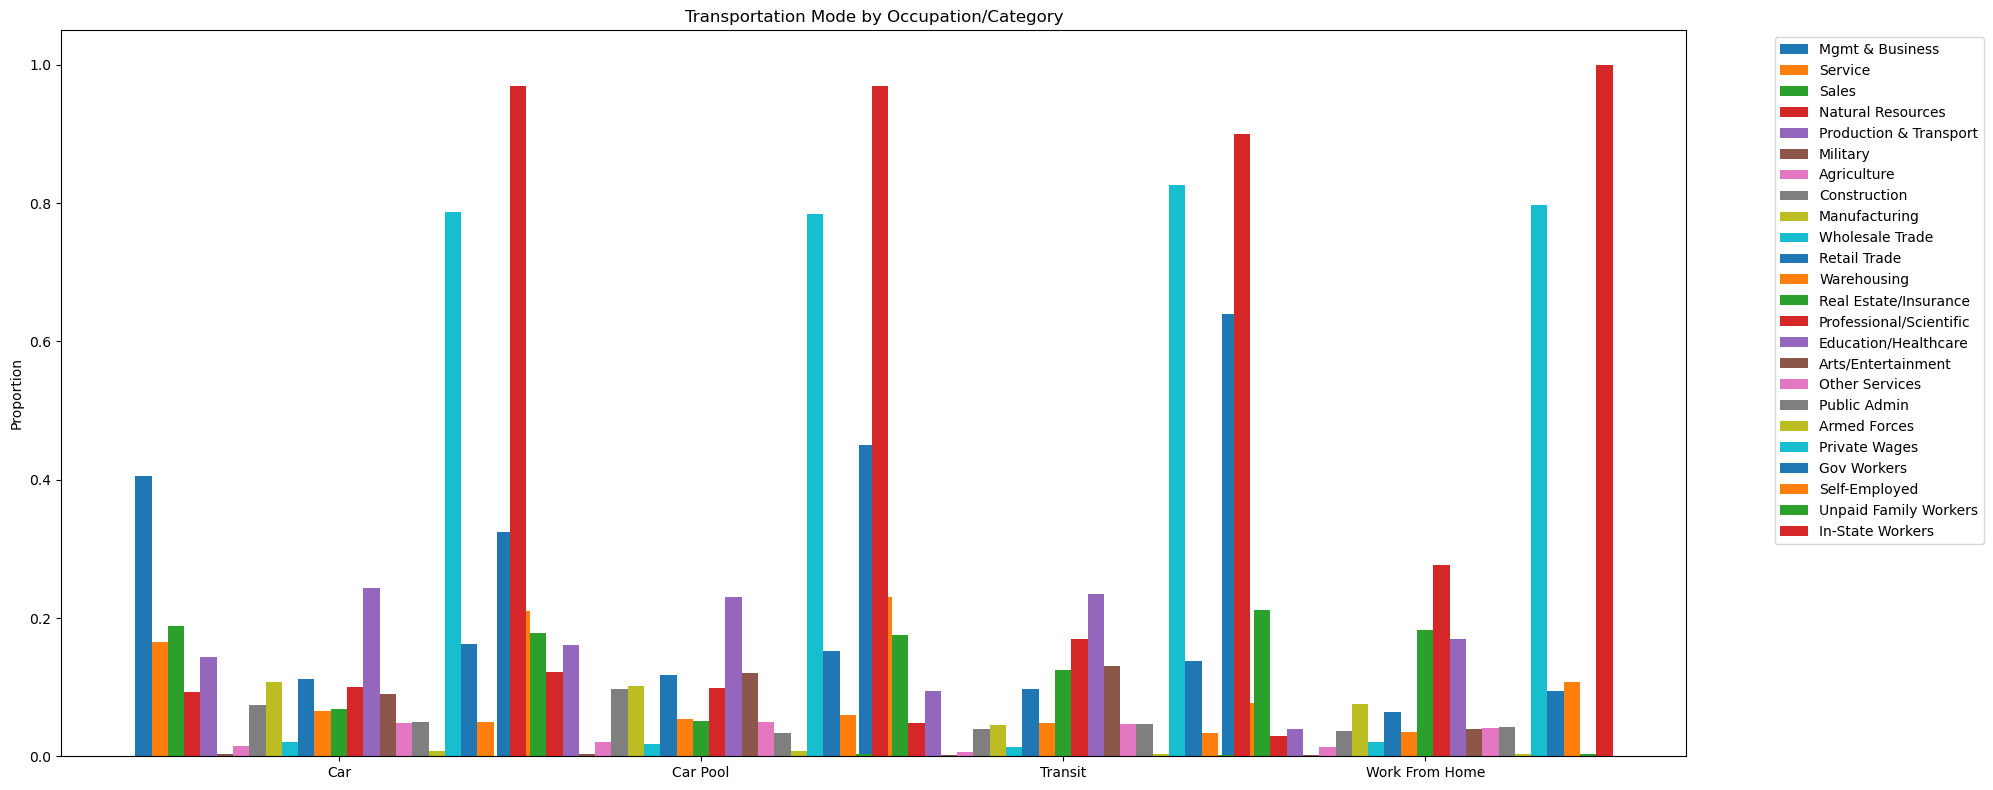

In [14]:
import matplotlib.pyplot as plt
import numpy as np
# graph 5:
# Categories
trans_modes = ["Car","Car Pool","Transit","Work From Home"]

# Values (each list corresponds to one category across 4 modes)
groups = {
    "Mgmt & Business": [0.406,0.325,0.450,0.639],
    "Service": [0.165,0.210,0.231,0.077],
    "Sales": [0.189,0.178,0.176,0.212],
    "Natural Resources": [0.093,0.122,0.048,0.030],
    "Production & Transport": [0.143,0.161,0.094,0.040],
    "Military": [0.004,0.004,0.002,0.002],
    "Agriculture": [0.015,0.020,0.006,0.013],
    "Construction": [0.074,0.097,0.040,0.037],
    "Manufacturing": [0.108,0.102,0.045,0.075],
    "Wholesale Trade": [0.021,0.018,0.013,0.021],
    "Retail Trade": [0.112,0.117,0.098,0.064],
    "Warehousing": [0.066,0.054,0.048,0.035],
    "Real Estate/Insurance": [0.068,0.051,0.125,0.182],
    "Professional/Scientific": [0.100,0.099,0.169,0.276],
    "Education/Healthcare": [0.244,0.231,0.234,0.169],
    "Arts/Entertainment": [0.09,0.12,0.13,0.04],
    "Other Services": [0.048,0.050,0.046,0.041],
    "Public Admin": [0.050,0.034,0.046,0.042],
    "Armed Forces": [0.008,0.008,0.003,0.003],
    "Private Wages": [0.787,0.785,0.827,0.797],
    "Gov Workers": [0.163,0.152,0.138,0.094],
    "Self-Employed": [0.049,0.060,0.033,0.107],
    "Unpaid Family Workers": [0.001,0.003,0.002,0.003],
    "In-State Workers": [0.97,0.97,0.90,1.00]
}

x = np.arange(len(trans_modes))
width = 0.045  # make bars very thin

plt.figure(figsize=(20,8))

# Loop through all groups
for i, (label, values) in enumerate(groups.items()):
    plt.bar(x + (i - len(groups)/2) * width, values, width, label=label)

plt.xticks(x, trans_modes)
plt.ylabel("Proportion")
plt.title("Transportation Mode by Occupation/Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


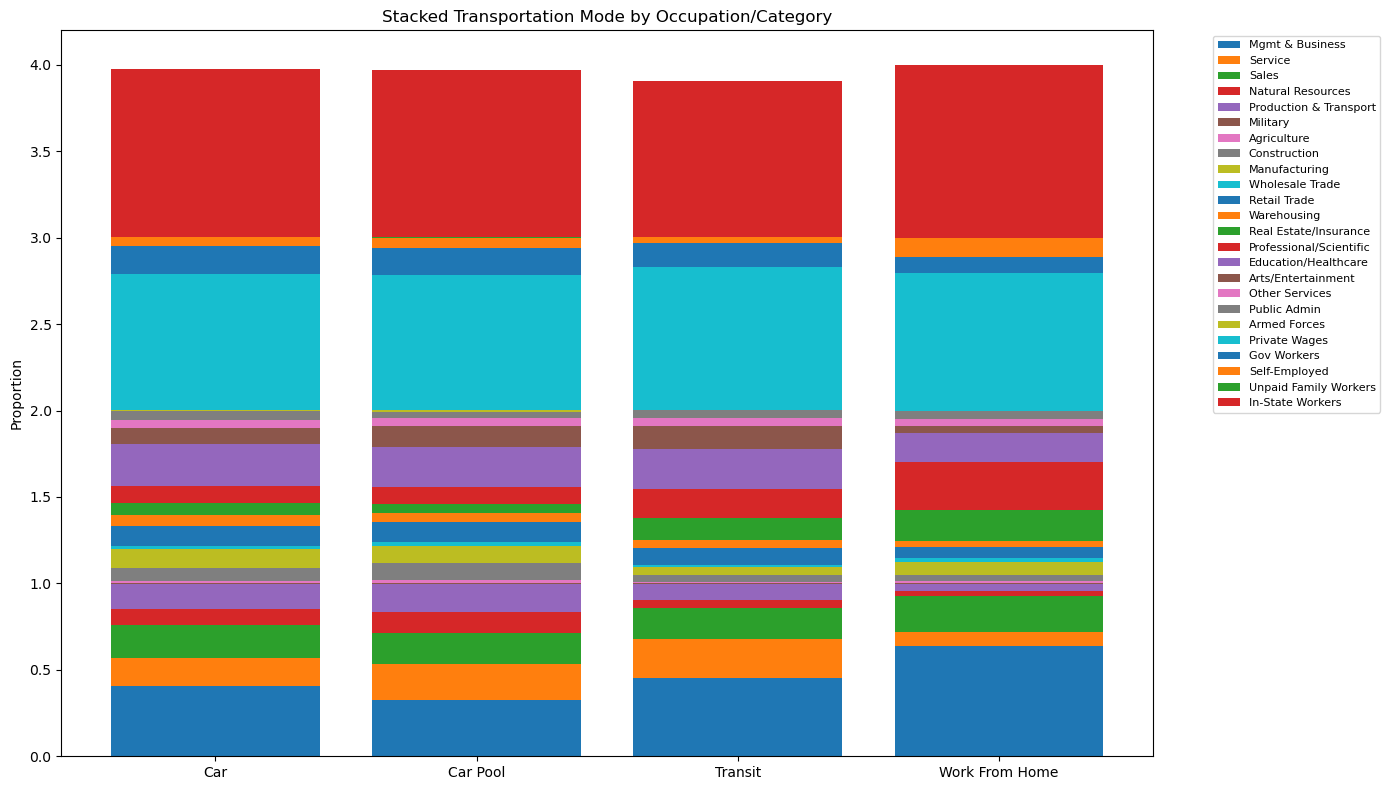

In [15]:
import matplotlib.pyplot as plt
import numpy as np
# Graph 5:Stacked Transportation Mode by Occupation/Category
# Same data dict as above
groups = {
    "Mgmt & Business": [0.406,0.325,0.450,0.639],
    "Service": [0.165,0.210,0.231,0.077],
    "Sales": [0.189,0.178,0.176,0.212],
    "Natural Resources": [0.093,0.122,0.048,0.030],
    "Production & Transport": [0.143,0.161,0.094,0.040],
    "Military": [0.004,0.004,0.002,0.002],
    "Agriculture": [0.015,0.020,0.006,0.013],
    "Construction": [0.074,0.097,0.040,0.037],
    "Manufacturing": [0.108,0.102,0.045,0.075],
    "Wholesale Trade": [0.021,0.018,0.013,0.021],
    "Retail Trade": [0.112,0.117,0.098,0.064],
    "Warehousing": [0.066,0.054,0.048,0.035],
    "Real Estate/Insurance": [0.068,0.051,0.125,0.182],
    "Professional/Scientific": [0.100,0.099,0.169,0.276],
    "Education/Healthcare": [0.244,0.231,0.234,0.169],
    "Arts/Entertainment": [0.09,0.12,0.13,0.04],
    "Other Services": [0.048,0.050,0.046,0.041],
    "Public Admin": [0.050,0.034,0.046,0.042],
    "Armed Forces": [0.008,0.008,0.003,0.003],
    "Private Wages": [0.787,0.785,0.827,0.797],
    "Gov Workers": [0.163,0.152,0.138,0.094],
    "Self-Employed": [0.049,0.060,0.033,0.107],
    "Unpaid Family Workers": [0.001,0.003,0.002,0.003],
    "In-State Workers": [0.97,0.97,0.90,1.00]
}
trans_modes = ["Car","Car Pool","Transit","Work From Home"]
x = np.arange(len(trans_modes))

plt.figure(figsize=(14,8))
bottom = np.zeros(len(trans_modes))  # start from zero

# Stack each group on top of the previous
for label, values in groups.items():
    plt.bar(trans_modes, values, bottom=bottom, label=label)
    bottom += np.array(values)
plt.ylabel("Proportion")
plt.title("Stacked Transportation Mode by Occupation/Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


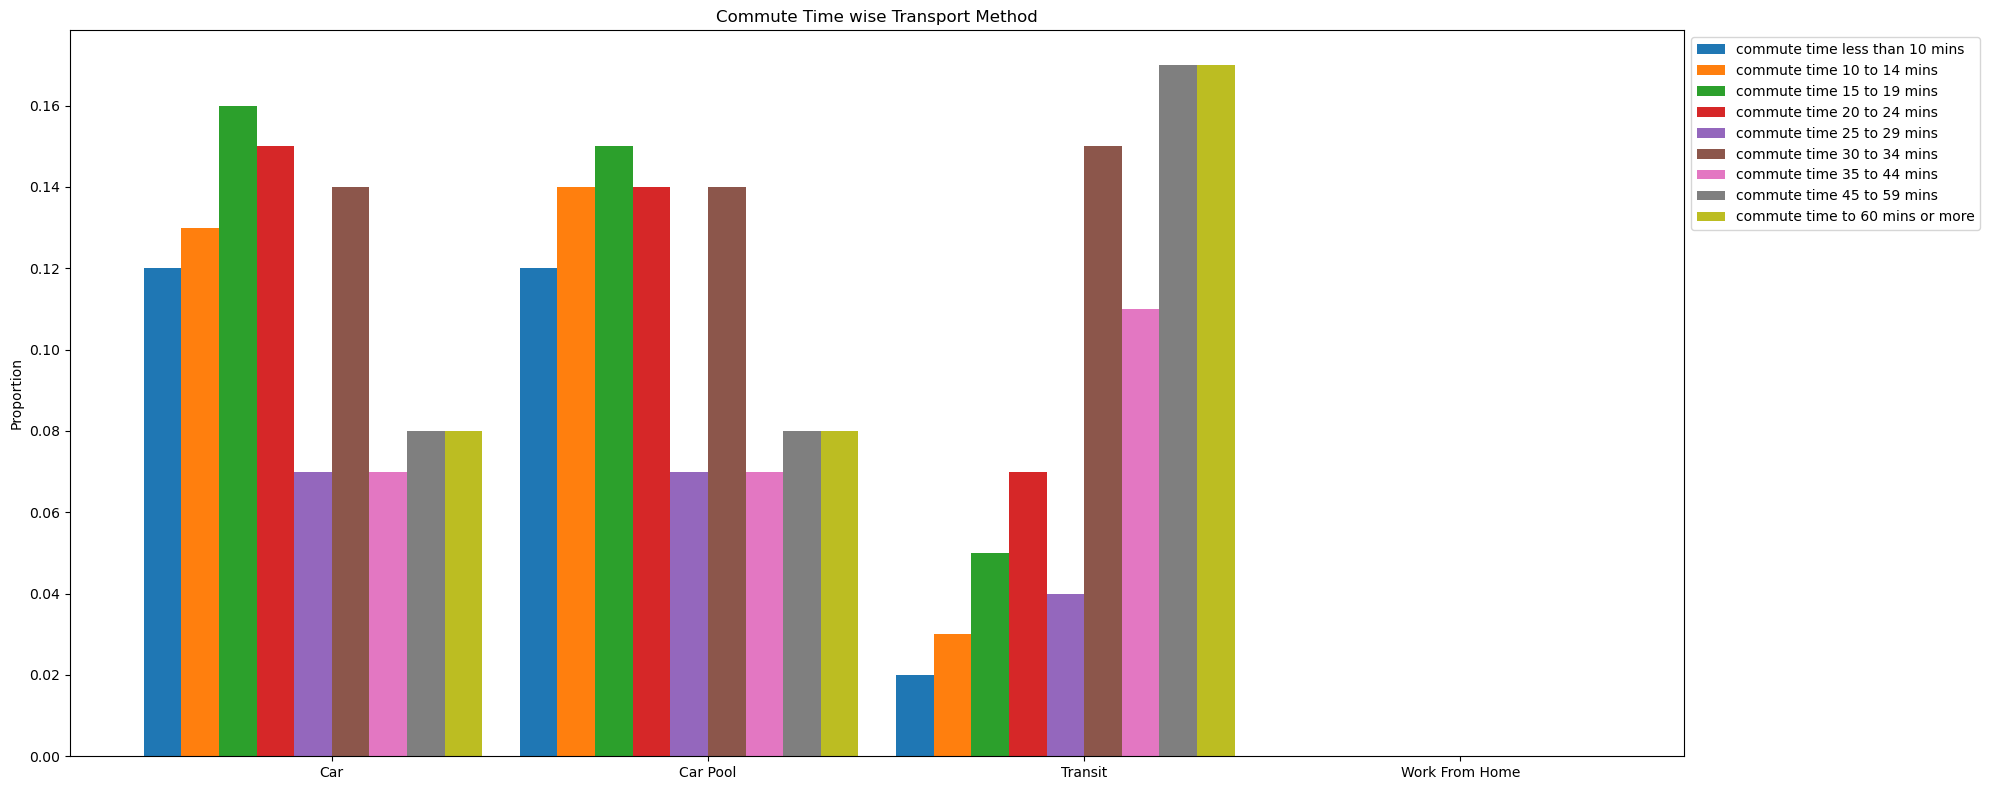

In [16]:
# graph 6:Commute Time wise Transport Method
# Categories

trans_modes = ["Car","Car Pool","Transit","Work From Home"]

# Values (each list corresponds to one category across 4 modes)
groups = {
    "commute time less than 10 mins": [0.12,0.12,0.02,0.00],
    "commute time 10 to 14 mins":[0.13,0.14,0.03,0.00],
    "commute time 15 to 19 mins":[0.16,0.15,0.05,0.00],
    "commute time 20 to 24 mins":[0.15,0.14,0.07,0.00],
    "commute time 25 to 29 mins":[0.07,0.07,0.04,0.00],
    "commute time 30 to 34 mins":[0.14,0.14,0.15,0.00],
    "commute time 35 to 44 mins":[0.07,0.07,0.11,0.00],
    "commute time 45 to 59 mins":[0.08,0.08,0.17,0.00],
    "commute time to 60 mins or more":[0.08,0.08,0.17,0.00]
}
x = np.arange(len(trans_modes))
width = 0.10  # make bars very thin
plt.figure(figsize=(20,8))
# Loop through all groups
for i, (label, values) in enumerate(groups.items()):
    plt.bar(x + (i - len(groups)/2) * width, values, width, label=label)
plt.xticks(x, trans_modes)
plt.ylabel("Proportion")
plt.title("Commute Time wise Transport Method")
plt.legend(bbox_to_anchor=(1.0,1), loc='upper left')
plt.tight_layout()
plt.show()
 

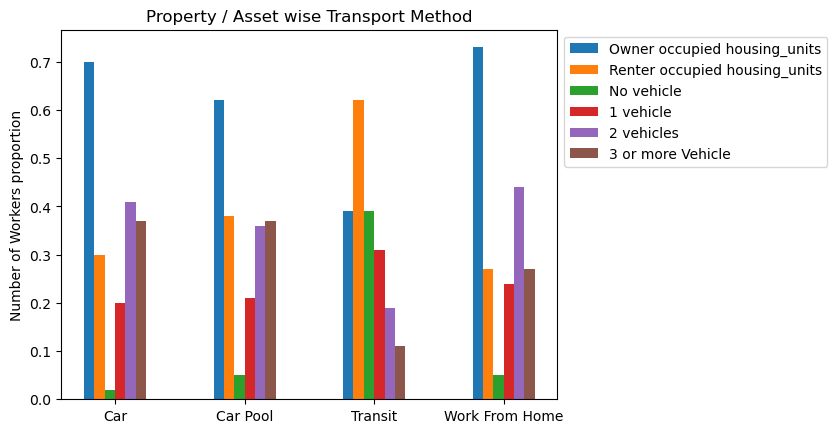

In [18]:
# Categories
# Graph 7: Property / Asset wise Transport Method
trans_modes = ["Car","Car Pool","Transit","Work From Home"]

# Values (each list corresponds to one category across 4 modes)

Owner_occupied_housing_units= [0.70,0.62,0.39,0.73]
Renter_occupied_housing_units=[0.30,0.38,0.62,0.27]
No_vehicle=[0.02,0.05,0.39,0.05]
one_vehicle=[0.20,0.21,0.31,0.24]
two_vehicle=[0.41,0.36,0.19,0.44]
three_or_more_vehicle=[0.37,0.37,0.11,0.27]

x = np.arange(len(trans_modes))
width = 0.08  # make bars very thin


#Plot bars side by side
plt.bar(x-2.5*width,Owner_occupied_housing_units,width,label="Owner occupied housing_units")
plt.bar(x-1.5*width,Renter_occupied_housing_units,width,label="Renter occupied housing_units")
plt.bar(x-0.5*width,No_vehicle,width,label="No vehicle")
plt.bar(x+0.5*width,one_vehicle,width,label="1 vehicle")
plt.bar(x+1.5*width,two_vehicle,width,label="2 vehicles")
plt.bar(x+2.5*width,three_or_more_vehicle,width,label="3 or more Vehicle")

#Formatting
plt.xticks(x,trans_modes)
plt.ylabel("Number of Workers proportion")
plt.title("Property / Asset wise Transport Method")
plt.legend(bbox_to_anchor=(1.0,1), loc='upper left')
plt.show()


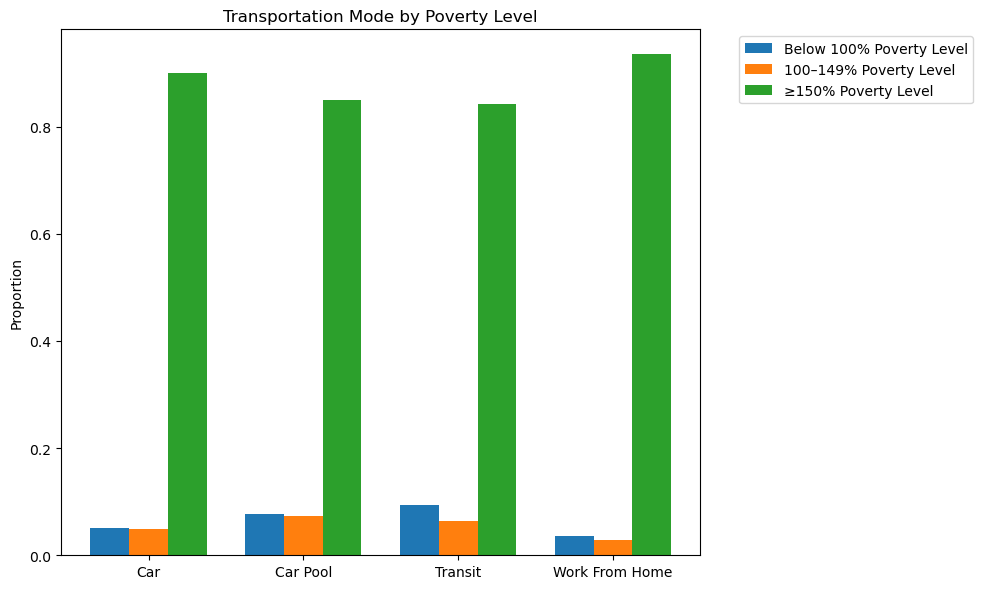

In [19]:
# Graph 8: Transportation Mode by Poverty Level
# Categories
trans_modes = ["Car","Car Pool","Transit","Work From Home"]

# Values 
below_100_poverty = [0.051,0.077,0.093,0.036]
poverty_100to149 = [0.049,0.074,0.064,0.029]
poverty_150plus  = [0.900,0.849,0.842,0.935]

x = np.arange(len(trans_modes))
width = 0.25  

plt.figure(figsize=(10,6))

# Grouped bars
plt.bar(x - width, below_100_poverty, width, label="Below 100% Poverty Level")
plt.bar(x, poverty_100to149, width, label="100–149% Poverty Level")
plt.bar(x + width, poverty_150plus, width, label="≥150% Poverty Level")

# Labels & legend
plt.xticks(x, trans_modes)
plt.ylabel("Proportion")
plt.title("Transportation Mode by Poverty Level")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [116]:
# Change Datatype objects into int for each columns
from sklearn.preprocessing import LabelEncoder
objlist=df.select_dtypes(include="object").columns
le=LabelEncoder()
for feat in objlist:
    df[feat]=le.fit_transform(df[feat].astype(str))
print(df.info())    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 1 to 4
Data columns (total 78 columns):
 #   Column                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                     --------------  -----  
 0   Transportation Method                                                                                      4 non-null      int64  
 1   Workers 16 years and over                                                                                  4 non-null      int64  
 2   16 to 19 years                                                                                             4 non-null      float64
 3   20 to 24 years                                                                                             4 non-null      float64
 4   25 to 44 years                                                                

C:\Users\rajes\AppData\Local\Temp\ipykernel_860\237395674.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\rajes\AppData\Local\Temp\ipykernel_860\237395674.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\rajes\AppData\Local\Temp\ipykernel_860\237395674.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

In [76]:
#categorical_columns=['Transportation Method']
#y=data.iloc[:,:1]
data['Transportation Method'] = data['Transportation Method'].map({
    'Total Estimate':0,
    'Car, truck, or van -- drove alone Estimate': 1,
    'Car, truck, or van -- carpooled Estimate': 2,
    'Public transportation (excluding taxicab) Estimate': 3,
    'Worked from home Estimate': 4
  })
y=data['Transportation Method']

# Step 5: Split data into training and testing

In [114]:

from sklearn.model_selection import train_test_split
X = new_df.drop('Transportation Method', axis=1)
y = new_df['Transportation Method']

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

# Step 6: Build and Train the Model

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
rfc=RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(xtrain,ytrain)

RandomForestClassifier(random_state=42)

In [101]:
y_pred=rfc.predict(xtest)
print("Accuracy",accuracy_score(ytest,y_pred))

Accuracy 0.0


In [102]:
from sklearn.linear_model import LogisticRegression

In [103]:
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=500)
model.fit(xtrain, ytrain)

C:\Users\rajes\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(max_iter=500, multi_class='multinomial')

# Step 7: Find the Prediction

In [104]:
y_pred = model.predict(xtest)
# Evaluation
print("Accuracy:", accuracy_score(ytest, y_pred))

Accuracy: 0.0


In [107]:
print("Train class distribution:")
print(ytrain.value_counts())

print("\nTest class distribution:")
print(ytest.value_counts())

print("\nUnique labels in ytrain:", ytrain.unique())
print("Unique labels in ytest:", ytest.unique())

Train class distribution:
Transportation Method
4    1
1    1
3    1
Name: count, dtype: int64

Test class distribution:
Transportation Method
2    1
Name: count, dtype: int64

Unique labels in ytrain: ['4' '1' '3']
Unique labels in ytest: ['2']


In [108]:
print("Total samples:", len(new_df))
print("Train:", len(xtrain), "Test:", len(xtest))


Total samples: 4
Train: 3 Test: 1
